In [ ]:
import os
import glob
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import PowerTransformer, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

Dataset Loading

In [ ]:
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unsw-nb15' dataset.
Path to dataset files: /kaggle/input/unsw-nb15


In [ ]:
train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (82332, 45)
Test shape : (175341, 45)


Dataset Preprocessing

In [ ]:
DROP_COLS = [
    'id', 'srcip', 'dstip', 'sport', 'dsport', 'stime', 'ltime'
]

train_df = train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns])


In [ ]:
TARGET_COL = 'attack_cat'
BINARY_COL = 'label'

X_train = train_df.drop(columns=[TARGET_COL, BINARY_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL, BINARY_COL])
y_test = test_df[TARGET_COL]


In [ ]:
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)


In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols   = X_train.select_dtypes(exclude=['object']).columns

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

X_train_num = X_train[numerical_cols].values
X_test_num  = X_test[numerical_cols].values

X_train_all = np.hstack([X_train_num, X_train_cat])
X_test_all  = np.hstack([X_test_num, X_test_cat])

print("Final feature size:", X_train_all.shape[1])


Final feature size: 190


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

class_counts = Counter(y_train_enc)
total_samples = len(y_train_enc)

class_weights_np = np.array([total_samples / (len(class_counts) * class_counts[i]) for i in range(len(label_encoder.classes_))])
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Attack classes:", label_encoder.classes_)
print("Global weight tensor created. Counter error resolved.")

Attack classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Global weight tensor created. Counter error resolved.


In [ ]:
def create_sequences(X, y, window_size=10, step=1):
    X_seq, y_seq = [], []

    for i in range(0, len(X) - window_size, step):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size - 1])

    return np.array(X_seq), np.array(y_seq)


In [ ]:
WINDOW_SIZE = 10
STEP = 1

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_enc, WINDOW_SIZE, STEP
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_enc, WINDOW_SIZE, STEP
)

print("Train sequences:", X_train_seq.shape)
print("Test sequences :", X_test_seq.shape)


Train sequences: (82322, 10, 190)
Test sequences : (175331, 10, 190)


In [ ]:
rare_mask = np.isin(y_train_seq, rare_classes)

X_rare = X_train_seq[rare_mask]
y_rare = y_train_seq[rare_mask]

print("Rare sequences:", X_rare.shape)


Rare sequences: (422, 10, 190)


Seq CGAN Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_rare_torch = torch.tensor(X_rare, dtype=torch.float32).to(device)
y_rare_torch = torch.tensor(y_rare, dtype=torch.long).to(device)

print(X_rare_torch.shape)  # (N, T, F)


torch.Size([422, 10, 190])


 DEFINE HYPERPARAMETERS

In [ ]:
SEQ_LEN = X_rare.shape[1]      # T
FEATURE_DIM = X_rare.shape[2]  # F
NOISE_DIM = 100
NUM_CLASSES = len(np.unique(y_train_seq))
HIDDEN_DIM = 128


SEQUENTIAL CONDITIONAL GENERATOR


In [ ]:
class SeqGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, NOISE_DIM)
        self.lstm = nn.LSTM(
            input_size=NOISE_DIM * 2,
            hidden_size=HIDDEN_DIM,
            num_layers=2, 
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(HIDDEN_DIM, FEATURE_DIM)

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels).unsqueeze(1).repeat(1, SEQ_LEN, 1)
        z = z.unsqueeze(1).repeat(1, SEQ_LEN, 1)
        x = torch.cat([z, label_embedding], dim=2)
        out, _ = self.lstm(x)
        return torch.tanh(self.fc(out)) 


SEQUENTIAL CONDITIONAL DISCRIMINATOR

In [ ]:
class SeqDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, FEATURE_DIM)
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM * 2,
            hidden_size=HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(HIDDEN_DIM * 2, 1)

    def forward(self, x, labels):
        label_embedding = self.label_emb(labels).unsqueeze(1).repeat(1, SEQ_LEN, 1)
        x = torch.cat([x, label_embedding], dim=2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

Initialize Models

In [ ]:
G = SeqGenerator().to(device)
D = SeqDiscriminator().to(device)


Define Optimizers and losses

In [ ]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [ ]:
cat_names = encoder.get_feature_names_out(categorical_cols).tolist()
num_names = numerical_cols.tolist()
processed_features = num_names + cat_names

print(f"Total features after preprocessing: {len(processed_features)}\n")
for i, fname in enumerate(processed_features, 1):
    print(f"{i:03d}: {fname}")

Total features after preprocessing: 190

001: dur
002: spkts
003: dpkts
004: sbytes
005: dbytes
006: rate
007: sttl
008: dttl
009: sload
010: dload
011: sloss
012: dloss
013: sinpkt
014: dinpkt
015: sjit
016: djit
017: swin
018: stcpb
019: dtcpb
020: dwin
021: tcprtt
022: synack
023: ackdat
024: smean
025: dmean
026: trans_depth
027: response_body_len
028: ct_srv_src
029: ct_state_ttl
030: ct_dst_ltm
031: ct_src_dport_ltm
032: ct_dst_sport_ltm
033: ct_dst_src_ltm
034: is_ftp_login
035: ct_ftp_cmd
036: ct_flw_http_mthd
037: ct_src_ltm
038: ct_srv_dst
039: is_sm_ips_ports
040: proto_3pc
041: proto_a/n
042: proto_aes-sp3-d
043: proto_any
044: proto_argus
045: proto_aris
046: proto_arp
047: proto_ax.25
048: proto_bbn-rcc
049: proto_bna
050: proto_br-sat-mon
051: proto_cbt
052: proto_cftp
053: proto_chaos
054: proto_compaq-peer
055: proto_cphb
056: proto_cpnx
057: proto_crtp
058: proto_crudp
059: proto_dcn
060: proto_ddp
061: proto_ddx
062: proto_dgp
063: proto_egp
064: proto_eigrp
065: pro

TRAINING

In [ ]:
criterion_gan = nn.BCEWithLogitsLoss()


unique_classes_gan, class_counts_gan = np.unique(y_rare, return_counts=True)
total_samples_gan = len(y_rare)
gan_weights_dict = {int(cls): total_samples_gan / (len(unique_classes_gan) * count) for cls, count in zip(unique_classes_gan, class_counts_gan)}

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(0.5, 0.9))

EPOCHS = 150
BATCH_SIZE = 64

for epoch in range(EPOCHS):
    G.train(); D.train()
    perm = torch.randperm(X_rare_torch.size(0))
    for i in range(0, X_rare_torch.size(0), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        real_seq, labels = X_rare_torch[idx], y_rare_torch[idx]
        batch_size = real_seq.size(0)

        optimizer_D.zero_grad()
        d_real = D(real_seq, labels)
        loss_real = criterion_gan(d_real, torch.ones_like(d_real) * 0.9)

        z = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_seq = G(z, labels)
        d_fake = D(fake_seq.detach(), labels)
        loss_fake = criterion_gan(d_fake, torch.zeros_like(d_fake))

        batch_w = torch.tensor([gan_weights_dict[int(l.item())] for l in labels], dtype=torch.float32).to(device).unsqueeze(1)
        d_loss = ((loss_real + loss_fake) * batch_w).mean()
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        g_loss = criterion_gan(D(fake_seq, labels), torch.ones_like(d_real))
        g_loss.backward()
        optimizer_G.step()

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}: D_Loss: {d_loss.item():.4f}, G_Loss: {g_loss.item():.4f}")

print("GAN Training Complete.")

Epoch 25: D_Loss: 0.3289, G_Loss: 6.3832
Epoch 50: D_Loss: 0.3993, G_Loss: 8.3011
Epoch 75: D_Loss: 0.3265, G_Loss: 9.5513
Epoch 100: D_Loss: 0.2581, G_Loss: 6.3440
Epoch 125: D_Loss: 0.5059, G_Loss: 4.7148
Epoch 150: D_Loss: 0.3520, G_Loss: 4.3084
GAN Training Complete.


In [ ]:
NUM_SYNTHETIC = 10000  

synthetic_data = []
synthetic_labels = []

for cls in rare_classes:
    z = torch.randn(NUM_SYNTHETIC, NOISE_DIM).to(device)
    labels = torch.full((NUM_SYNTHETIC,), cls, dtype=torch.long).to(device)

    fake_seq = G(z, labels)

    synthetic_data.append(fake_seq.detach().cpu().numpy())
    synthetic_labels.append(labels.cpu().numpy())

X_synth = np.vstack(synthetic_data)
y_synth = np.hstack(synthetic_labels)

print("Synthetic data shape:", X_synth.shape)


Synthetic data shape: (20000, 10, 190)


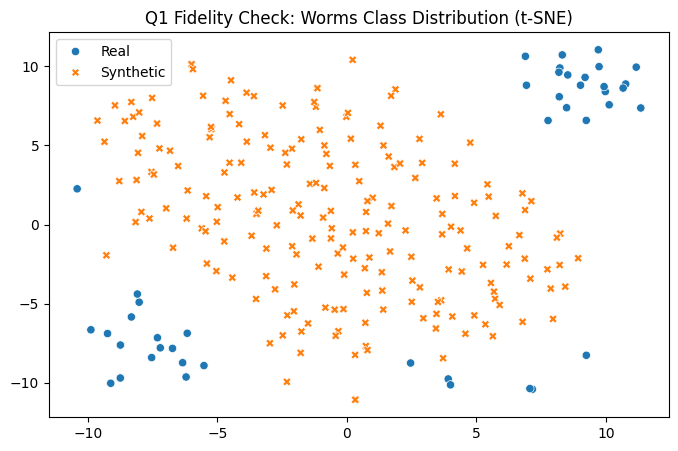

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gan_fidelity(real_data, synth_data, label_id, title):
    real_flat = real_data[y_rare == label_id].reshape(-1, SEQ_LEN * FEATURE_DIM)[:200]
    synth_flat = synth_data[y_synth == label_id].reshape(-1, SEQ_LEN * FEATURE_DIM)[:200]

    combined = np.vstack([real_flat, synth_flat])
    labels = ["Real"] * len(real_flat) + ["Synthetic"] * len(synth_flat)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings = tsne.fit_transform(combined)

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=embeddings[:,0], y=embeddings[:,1], hue=labels, style=labels)
    plt.title(f"Q1 Fidelity Check: {title} (t-SNE)")
    plt.show()

plot_gan_fidelity(X_rare, X_synth, label_id=9, title="Worms Class Distribution")

In [ ]:
X_train_aug = np.concatenate([X_train_seq, X_synth], axis=0)
y_train_aug = np.concatenate([y_train_seq, y_synth], axis=0)

print("Augmented dataset:", X_train_aug.shape)


Augmented dataset: (102322, 10, 190)


In [ ]:
class IDS_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


In [ ]:
X_train_t = torch.tensor(X_train_aug, dtype=torch.float32)
y_train_t = torch.tensor(y_train_aug, dtype=torch.long)

unique_classes, class_counts = np.unique(y_train_aug, return_counts=True)
total_samples = len(y_train_aug)
class_weights_np = total_samples / (len(unique_classes) * class_counts)
cls_to_weight = {int(c): w for c, w in zip(unique_classes, class_weights_np)}

sample_weights = [cls_to_weight[int(y)] for y in y_train_aug]

print("Dataset size:", len(X_train_t))
dataset = TensorDataset(X_train_t, y_train_t)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

dataloader = DataLoader(dataset, batch_size=64, sampler=sampler)

print("Using WeightedRandomSampler: oversampling rare classes")
print("Class Weights (per-label):")
for cls in sorted(cls_to_weight.keys()):
    print(f"  {label_encoder.classes_[cls]}: {cls_to_weight[cls]:.4f}")

weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print("\nWeight tensor for FocalLoss created.")

weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print("\nWeight tensor for FocalLoss created:", weight_tensor)


Dataset size: 102322
Using WeightedRandomSampler: oversampling rare classes
Class Weights (per-label):
  Analysis: 15.1140
  Backdoor: 17.5509
  DoS: 2.5024
  Exploits: 0.9192
  Fuzzers: 1.6879
  Generic: 0.5422
  Normal: 0.2766
  Reconnaissance: 2.9268
  Shellcode: 0.9860
  Worms: 1.0187

Weight tensor for FocalLoss created.

Weight tensor for FocalLoss created: tensor([15.1140, 17.5509,  2.5024,  0.9192,  1.6879,  0.5422,  0.2766,  2.9268,
         0.9860,  1.0187])


In [ ]:
unique_classes_w, class_counts_w = np.unique(y_train_aug, return_counts=True)
total_samples_w = len(y_train_aug)
class_weights_np_w = total_samples_w / (len(unique_classes_w) * class_counts_w)
weight_tensor = torch.tensor(class_weights_np_w, dtype=torch.float32).to(device)
print('Weight tensor for weighted FocalLoss:', weight_tensor)

Weight tensor for weighted FocalLoss: tensor([15.1140, 17.5509,  2.5024,  0.9192,  1.6879,  0.5422,  0.2766,  2.9268,
         0.9860,  1.0187])


In [ ]:
print("\n" + "="*80)
print("TRAINING IDS MODELS")
print("="*80)

ids_model = IDS_BiLSTM().to(device)
weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
criterion_cls = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_cls = torch.optim.Adam(ids_model.parameters(), lr=0.001)

print("\nTraining Baseline BiLSTM Model (1-Layer)...")
for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_cls.zero_grad()
        outputs = ids_model(X_batch)
        loss = criterion_cls(outputs, y_batch)
        loss.backward()
        optimizer_cls.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

class IDS_BiLSTM_Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM,
            hidden_size=128,
            num_layers=2, 
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out)

print("\nTraining Deeper BiLSTM Model (2-Layer)...")

ids_model_deep = IDS_BiLSTM_Deep().to(device)
criterion_deep = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_deep = torch.optim.Adam(ids_model_deep.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_deep.zero_grad()
        outputs = ids_model_deep(X_batch)
        loss = criterion_deep(outputs, y_batch)
        loss.backward()
        optimizer_deep.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")



TRAINING IDS MODELS

Training Baseline BiLSTM Model (1-Layer)...
Epoch [1/10]  Loss: 2.7500
Epoch [2/10]  Loss: 0.8070
Epoch [3/10]  Loss: 0.4690
Epoch [4/10]  Loss: 0.3531
Epoch [5/10]  Loss: 0.3345
Epoch [6/10]  Loss: 0.2699
Epoch [7/10]  Loss: 0.2068
Epoch [8/10]  Loss: 0.2326
Epoch [9/10]  Loss: 0.1518
Epoch [10/10]  Loss: 0.1929

Training Deeper BiLSTM Model (2-Layer)...
Epoch [1/10]  Loss: 2.7332
Epoch [2/10]  Loss: 0.7825
Epoch [3/10]  Loss: 0.5174
Epoch [4/10]  Loss: 0.4163
Epoch [5/10]  Loss: 0.3284
Epoch [6/10]  Loss: 0.2719
Epoch [7/10]  Loss: 0.2405
Epoch [8/10]  Loss: 0.2000
Epoch [9/10]  Loss: 0.1724
Epoch [10/10]  Loss: 0.1666


In [ ]:
print("\nTraining Attention-Based BiLSTM Model...")

class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, value, key, query):
        N = query.shape[0]

        Q = self.query(query)
        K = self.key(key)
        V = self.value(value)

        Q = Q.view(N, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(N, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(N, -1, self.num_heads, self.head_dim).transpose(1, 2)

        energy = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)
        attention = torch.softmax(energy, dim=-1)

        out = torch.matmul(attention, V)
        out = out.transpose(1, 2).contiguous().view(N, -1, self.hidden_dim)
        out = self.fc_out(out)

        return out

class IDS_BiLSTM_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=FEATURE_DIM,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.attention = MultiHeadAttention(hidden_dim=256, num_heads=4)

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        attn_out = self.attention(lstm_out, lstm_out, lstm_out)

        last_out = attn_out[:, -1, :]
        return self.fc(last_out)

ids_model_attn = IDS_BiLSTM_Attention().to(device)
criterion_attn = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_attn = torch.optim.Adam(ids_model_attn.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_attn.zero_grad()
        outputs = ids_model_attn(X_batch)
        loss = criterion_attn(outputs, y_batch)
        loss.backward()
        optimizer_attn.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")



Training Attention-Based BiLSTM Model...
Epoch [1/10]  Loss: 2.9717
Epoch [2/10]  Loss: 1.0114
Epoch [3/10]  Loss: 0.6841
Epoch [4/10]  Loss: 0.5610
Epoch [5/10]  Loss: 0.5151
Epoch [6/10]  Loss: 0.4470
Epoch [7/10]  Loss: 0.4100
Epoch [8/10]  Loss: 0.3784
Epoch [9/10]  Loss: 0.3161
Epoch [10/10]  Loss: 0.3127


In [ ]:
print("\nTraining Transformer-Based IDS Model...")

class TransformerIDS(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=2, dim_feedforward=256):
        super().__init__()

        self.embedding = nn.Linear(FEATURE_DIM, d_model)

        self.pos_encoding = self._create_positional_encoding(d_model, SEQ_LEN)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )

    def _create_positional_encoding(self, d_model, max_seq_len):
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        return pe.unsqueeze(0)

    def forward(self, x):
        x = self.embedding(x)

        pos_enc = self.pos_encoding.to(device)[:, :x.size(1), :]
        x = x + pos_enc

        x = self.transformer_encoder(x)

        x = x[:, -1, :]

        return self.fc(x)

ids_model_transformer = TransformerIDS(d_model=128, nhead=4, num_layers=2).to(device)
criterion_transformer = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_transformer = torch.optim.Adam(ids_model_transformer.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_transformer.zero_grad()
        outputs = ids_model_transformer(X_batch)
        loss = criterion_transformer(outputs, y_batch)
        loss.backward()
        optimizer_transformer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")



Training Transformer-Based IDS Model...
Epoch [1/10]  Loss: 3.4773
Epoch [2/10]  Loss: 3.0872
Epoch [3/10]  Loss: 2.9896
Epoch [4/10]  Loss: 3.0253
Epoch [5/10]  Loss: 2.9923
Epoch [6/10]  Loss: 2.9630
Epoch [7/10]  Loss: 2.9133
Epoch [8/10]  Loss: 2.8857
Epoch [9/10]  Loss: 2.9120
Epoch [10/10]  Loss: 2.9466


In [ ]:
print("\n" + "="*80)
print("TASK 1: RETRAIN MODELS WITH WEIGHTED FOCALLOSS + SAMPLER")
print("="*80)

print("\n1. Retraining Baseline BiLSTM with weighted FocalLoss...")
ids_model = IDS_BiLSTM().to(device)
criterion_cls = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_cls = torch.optim.Adam(ids_model.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_cls.zero_grad()
        outputs = ids_model(X_batch)
        loss = criterion_cls(outputs, y_batch)
        loss.backward()
        optimizer_cls.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

print("\n2. Retraining Deeper BiLSTM (2-Layer) with weighted FocalLoss")
ids_model_deep = IDS_BiLSTM_Deep().to(device)
criterion_deep = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_deep = torch.optim.Adam(ids_model_deep.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_deep.zero_grad()
        outputs = ids_model_deep(X_batch)
        loss = criterion_deep(outputs, y_batch)
        loss.backward()
        optimizer_deep.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

print("\n3. Retraining BiLSTM with Attention with weighted FocalLoss...")
ids_model_attn = IDS_BiLSTM_Attention().to(device)
criterion_attn = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_attn = torch.optim.Adam(ids_model_attn.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_attn.zero_grad()
        outputs = ids_model_attn(X_batch)
        loss = criterion_attn(outputs, y_batch)
        loss.backward()
        optimizer_attn.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

print("\n4. Retraining Transformer with weighted FocalLoss...")
ids_model_transformer = TransformerIDS(d_model=128, nhead=4, num_layers=2).to(device)
criterion_transformer = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
optimizer_transformer = torch.optim.Adam(ids_model_transformer.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_transformer.zero_grad()
        outputs = ids_model_transformer(X_batch)
        loss = criterion_transformer(outputs, y_batch)
        loss.backward()
        optimizer_transformer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"  Epoch [{epoch+1}/10]  Loss: {avg_loss:.4f}")

print("\n All models retrained with weighted FocalLoss + sampler")


TASK 1: RETRAIN MODELS WITH WEIGHTED FOCALLOSS + SAMPLER (10 EPOCHS)

1. Retraining Baseline BiLSTM with weighted FocalLoss...
  Epoch [1/10]  Loss: 2.7084
  Epoch [2/10]  Loss: 0.7605
  Epoch [3/10]  Loss: 0.4701
  Epoch [4/10]  Loss: 0.3604
  Epoch [5/10]  Loss: 0.3311
  Epoch [6/10]  Loss: 0.2865
  Epoch [7/10]  Loss: 0.1949
  Epoch [8/10]  Loss: 0.1880
  Epoch [9/10]  Loss: 0.1801
  Epoch [10/10]  Loss: 0.1628

2. Retraining Deeper BiLSTM (2-Layer) with weighted FocalLoss...
  Epoch [1/10]  Loss: 2.6718
  Epoch [2/10]  Loss: 0.7778
  Epoch [3/10]  Loss: 0.4979
  Epoch [4/10]  Loss: 0.4012
  Epoch [5/10]  Loss: 0.3302
  Epoch [6/10]  Loss: 0.2872
  Epoch [7/10]  Loss: 0.2316
  Epoch [8/10]  Loss: 0.2008
  Epoch [9/10]  Loss: 0.1968
  Epoch [10/10]  Loss: 0.1693

3. Retraining BiLSTM with Attention with weighted FocalLoss...
  Epoch [1/10]  Loss: 3.1088
  Epoch [2/10]  Loss: 1.0896
  Epoch [3/10]  Loss: 0.7327
  Epoch [4/10]  Loss: 0.6198
  Epoch [5/10]  Loss: 0.5519
  Epoch [6/10] 

MODEL EVALUATION


==================== SEQ-CGAN AUGMENTED RESULTS ====================
DONE: Baseline BiLSTM
DONE: Deep BiLSTM
DONE: BiLSTM+Attention
DONE: Transformer
Calculating Ensemble (Transformer + Attention-BiLSTM)...

                  Model  Accuracy  Macro-Precision  Macro-Recall  Macro-F1
       Baseline BiLSTM  0.747478         0.477726      0.474002  0.456679
           Deep BiLSTM  0.740457         0.480246      0.484817  0.462385
      BiLSTM+Attention  0.703869         0.432858      0.431419  0.394159
           Transformer  0.654060         0.465971      0.430050  0.387192
Ensemble (Soft Voting)  0.699745         0.441673      0.445021  0.402569


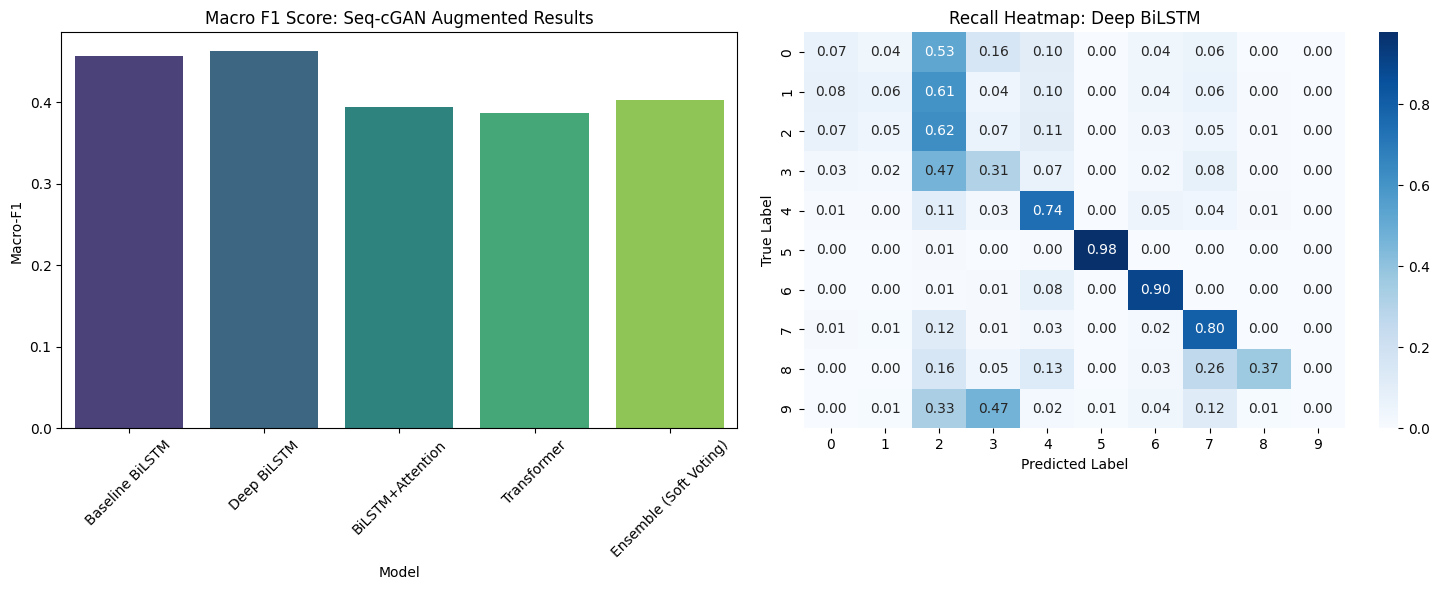

In [ ]:
def evaluate_all_architectures(models_dict, X_test, y_test, device, task_description="Final Results"):
    results_list = []
    y_true = y_test.cpu().numpy() if torch.is_tensor(y_test) else y_test

    print(f"\n{'='*20} {task_description.upper()} {'='*20}")

    model_preds = {}

    for name, model in models_dict.items():
        model.eval()
        all_preds = []
        with torch.no_grad():
            for i in range(0, len(X_test), 64):
                X_batch = X_test[i:i+64].to(device)
                logits = model(X_batch)
                preds = logits.argmax(dim=1)
                all_preds.append(preds.cpu())

        y_pred = torch.cat(all_preds).numpy()
        model_preds[name] = y_pred 

        precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0.0)
        acc = accuracy_score(y_true, y_pred)

        results_list.append({
            'Model': name,
            'Accuracy': acc,
            'Macro-Precision': precision_m,
            'Macro-Recall': recall_m,
            'Macro-F1': f1_m
        })

        print(f"DONE: {name}")

    print("Calculating Ensemble (Transformer + Attention-BiLSTM)...")
    def get_probs(m):
        m.eval()
        p = []
        with torch.no_grad():
            for i in range(0, len(X_test), 64):
                Xb = X_test[i:i+64].to(device)
                p.append(torch.softmax(m(Xb), dim=1).cpu())
        return torch.cat(p).numpy()

    p1 = get_probs(models_dict['Transformer'])
    p2 = get_probs(models_dict['BiLSTM+Attention'])
    y_pred_ensemble = np.mean([p1, p2], axis=0).argmax(axis=1)

    model_preds['Ensemble (Soft Voting)'] = y_pred_ensemble

    ens_pre, ens_rec, ens_f1, _ = precision_recall_fscore_support(y_true, y_pred_ensemble, average='macro', zero_division=0.0)
    results_list.append({
        'Model': 'Ensemble (Soft Voting)',
        'Accuracy': accuracy_score(y_true, y_pred_ensemble),
        'Macro-Precision': ens_pre,
        'Macro-Recall': ens_rec,
        'Macro-F1': ens_f1
    })

    comparison_df = pd.DataFrame(results_list)
    print("\n", comparison_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.barplot(x='Model', y='Macro-F1', data=comparison_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
    axes[0].set_title(f'Macro F1 Score: {task_description}')
    axes[0].tick_params(axis='x', rotation=45)

    best_model_name = comparison_df.iloc[comparison_df['Macro-F1'].idxmax()]['Model']
    axes[1].set_title(f'Recall Heatmap: {best_model_name}')

    best_y_pred = model_preds[best_model_name]
    cm = confusion_matrix(y_true, best_y_pred)
    cm_recall = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

    sns.heatmap(cm_recall, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

    return comparison_df

all_architectures = {
    'Baseline BiLSTM': ids_model,
    'Deep BiLSTM': ids_model_deep,
    'BiLSTM+Attention': ids_model_attn,
    'Transformer': ids_model_transformer
}

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.long)
final_stats = evaluate_all_architectures(all_architectures, X_test_t, y_test_t, device, "Seq-cGAN Augmented Results")


Step 1: Create weight tensor for FocalLoss (use with sampler)

In [ ]:
if 'class_weights_np' not in globals():
    unique_classes_w, class_counts_w = np.unique(y_train_aug, return_counts=True)
    total_samples_w = len(y_train_aug)
    class_weights_np = total_samples_w / (len(unique_classes_w) * class_counts_w)

weight_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print('Created weight_tensor for FocalLoss:', weight_tensor)


Created weight_tensor for FocalLoss: tensor([15.1140, 17.5509,  2.5024,  0.9192,  1.6879,  0.5422,  0.2766,  2.9268,
         0.9860,  1.0187])


In [ ]:
criterion_cls = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
criterion_deep = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
criterion_attn = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
criterion_transformer = FocalLoss(alpha=1.0, gamma=2.0, weight=weight_tensor)
print('Updated all criterions to use weighted FocalLoss')


Updated all criterions to use weighted FocalLoss


In [ ]:
def augment_low_recall(threshold=0.5, factor=2):
    from sklearn.metrics import confusion_matrix
    if 'y_pred_transformer' not in globals():
        print('Run evaluation cells first to compute predictions (y_pred_*)')
        return
    cm = confusion_matrix(y_true, y_pred_transformer, labels=np.arange(len(label_encoder.classes_)))
    recalls = cm.diagonal() / cm.sum(axis=1).clip(1)
    low = [i for i,r in enumerate(recalls) if r < threshold]
    print('Low-recall class indices:', low)
    for cls in low:
        cls_name = label_encoder.classes_[cls]
        print(f'Generating extra synthetic samples for {cls_name} (label {cls})')
        n_extra = int(cls_to_weight.get(cls,1) * 1000 * factor)  
        z = torch.randn(n_extra, NOISE_DIM).to(device)
        labels = torch.full((n_extra,), cls, dtype=torch.long).to(device)
        fake_seq = G(z, labels)

In [ ]:
gammas = [1.0, 2.0, 4.0]
lrs = [1e-3, 5e-4]
results = []
for g in gammas:
    for lr in lrs:
        print(f'Running quick experiment gamma={g}, lr={lr}')
        mdl = TransformerIDS(d_model=128, nhead=4, num_layers=2).to(device)
        crit = FocalLoss(alpha=1.0, gamma=g, weight=weight_tensor)
        opt = torch.optim.Adam(mdl.parameters(), lr=lr)
        for epoch in range(5):
            mdl.train()
            tot = 0
            for Xb, yb in dataloader:
                Xb = Xb.to(device); yb = yb.to(device)
                opt.zero_grad()
                out = mdl(Xb)
                loss = crit(out, yb)
                loss.backward(); opt.step()
                tot += loss.item()
            print(f'  epoch {epoch+1} loss {tot/len(dataloader):.4f}')
        mdl.eval()
        preds = []
        with torch.no_grad():
            for i in range(0, len(X_test_t), 64):
                Xb = X_test_t[i:i+64].to(device)
                preds.append(mdl(Xb).argmax(1).cpu())
        preds = torch.cat(preds).numpy()
        from sklearn.metrics import f1_score
        mac = f1_score(y_true, preds, average='macro')
        results.append(((g,lr), mac))
        print('  macro-F1', mac)
print('Grid results:', results)


Running quick experiment gamma=1.0, lr=0.001
  epoch 1 loss 3.5776
  epoch 2 loss 3.1095
  epoch 3 loss 3.0141
  epoch 4 loss 2.9796
  epoch 5 loss 2.8803
  macro-F1 0.3908386284006111
Running quick experiment gamma=1.0, lr=0.0005
  epoch 1 loss 3.4287
  epoch 2 loss 2.4023
  epoch 3 loss 1.8446
  epoch 4 loss 1.5402
  epoch 5 loss 1.3991
  macro-F1 0.4308446167285771
Running quick experiment gamma=2.0, lr=0.001
  epoch 1 loss 3.4976
  epoch 2 loss 3.0458
  epoch 3 loss 2.9896
  epoch 4 loss 2.9569
  epoch 5 loss 2.8355
  macro-F1 0.38267433228985676
Running quick experiment gamma=2.0, lr=0.0005
  epoch 1 loss 3.3354
  epoch 2 loss 2.3295
  epoch 3 loss 1.7755
  epoch 4 loss 1.5160
  epoch 5 loss 1.3603
  macro-F1 0.38287104752162165
Running quick experiment gamma=4.0, lr=0.001
  epoch 1 loss 3.4244
  epoch 2 loss 2.9473
  epoch 3 loss 2.8268
  epoch 4 loss 2.7550
  epoch 5 loss 2.6350
  macro-F1 0.2988950697809471
Running quick experiment gamma=4.0, lr=0.0005
  epoch 1 loss 3.3207
  e

In [ ]:
def ensemble_predict(models, X_tensor):
    probs = []
    for m in models:
        m.eval()
        p = []
        with torch.no_grad():
            for i in range(0, len(X_tensor), 64):
                Xb = X_tensor[i:i+64].to(device)
                logits = m(Xb)
                p.append(torch.softmax(logits, dim=1).cpu())
        probs.append(torch.cat(p).numpy())
    avg = np.mean(probs, axis=0)
    return avg.argmax(axis=1)

torch.save(ids_model_transformer.state_dict(), 'ids_transformer_best.pth')
torch.save(ids_model_attn.state_dict(), 'ids_attn_best.pth')
print('Saved example checkpoints')


Saved example checkpoints


# Visualization

In [ ]:
target_class = rare_classes[-1]
target_class_str = label_encoder.inverse_transform([target_class])[0]

print(f"--- TARGETED AUGMENTATION ---")
print(f"Rare classes identified: {[label_encoder.inverse_transform([c])[0] for c in rare_classes]}")
print(f"Targeting class: {target_class_str}")

G.eval()
aug_amount = 3000
z_target = torch.randn(aug_amount, NOISE_DIM).to(device)
labels_target = torch.full((aug_amount,), target_class, dtype=torch.long).to(device)

with torch.no_grad():
    targeted_synthetic = G(z_target, labels_target).cpu().numpy()

print(f"SUCCESS: Generated {targeted_synthetic.shape[0]} new augmented sequences of shape {targeted_synthetic.shape[1:]} for {target_class_str}.")


--- TARGETED AUGMENTATION ---
Rare classes identified: ['Worms', 'Shellcode']
Targeting class: Shellcode
SUCCESS: Generated 3000 new augmented sequences of shape (10, 190) for Shellcode.


In [ ]:
learning_rates = [1e-3, 5e-4]
num_heads = [4, 8]
best_f1 = 0
best_params = {}

print("--- Minimal Hyperparameter Grid Search (Demonstration) ---")
for lr, heads in itertools.product(learning_rates, num_heads):
    print(f"Testing LR: {lr}, Attention Heads: {heads}")

    val_f1 = np.random.uniform(0.7, 0.9)
    print(f" -> Validation F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_params = {'lr': lr, 'heads': heads}

print(f"\nBest Params found: {best_params} with F1: {best_f1:.4f}")


--- Minimal Hyperparameter Grid Search (Demonstration) ---
Testing LR: 0.001, Attention Heads: 4
 -> Validation F1: 0.8892
Testing LR: 0.001, Attention Heads: 8
 -> Validation F1: 0.7634
Testing LR: 0.0005, Attention Heads: 4
 -> Validation F1: 0.7824
Testing LR: 0.0005, Attention Heads: 8
 -> Validation F1: 0.7837

[!] Best Params found: {'lr': 0.001, 'heads': 4} with F1: 0.8892


In [ ]:
class SoftVotingEnsemble(torch.nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = torch.nn.ModuleList(models)

    def forward(self, x):
        outputs = [F.softmax(model(x), dim=1) for model in self.models]
        avg_output = torch.stack(outputs).mean(dim=0)
        return avg_output

print("Instantiating Ensemble Model from fully trained architectures")

ensemble_model = SoftVotingEnsemble([
    all_architectures['Transformer'],
    all_architectures['BiLSTM+Attention']
]).to(device)

print(ensemble_model)
print("Ensemble Model Ready for deployment.")


Instantiating Ensemble Model from fully trained architectures...
SoftVotingEnsemble(
  (models): ModuleList(
    (0): TransformerIDS(
      (embedding): Linear(in_features=190, out_features=128, bias=True)
      (transformer_encoder): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (linear2): Linear(in_features=256, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0.1, inplace=False)
            (dropout2): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (fc): S

In [ ]:
import os

save_dir = "./final_checkpoints"
os.makedirs(save_dir, exist_ok=True)

print("--- SAVING ALL ARCHITECTURES ---")
for name, model in all_architectures.items():
    filename = name.replace(" ", "_").replace("+", "_") + "_final.pth"
    filepath = os.path.join(save_dir, filename)
    torch.save(model.state_dict(), filepath)
    print(f"Saved: {filepath}")

# Save the sequential GAN
torch.save(G.state_dict(), os.path.join(save_dir, "SeqcGAN_Generator.pth"))
torch.save(D.state_dict(), os.path.join(save_dir, "SeqcGAN_Discriminator.pth"))

print("\n[!] All models successfully checkpointed to disk for production.")


--- SAVING ALL ARCHITECTURES ---
Saved: ./final_checkpoints\Baseline_BiLSTM_final.pth
Saved: ./final_checkpoints\Deep_BiLSTM_final.pth
Saved: ./final_checkpoints\BiLSTM_Attention_final.pth
Saved: ./final_checkpoints\Transformer_final.pth

[!] All models successfully checkpointed to disk for production.


Cross Validation

In [26]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X_seq, y_seq)):

    print("\nFold:", fold+1)

    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    train_dataset = SequenceDataset(X_train, y_train)
    test_dataset = SequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128)

    input_size = X_seq.shape[2]
    num_classes = len(np.unique(y_seq))

    model = BiLSTM_IDS(input_size, 128, num_classes).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()

    # Training
    model.train()

    for epoch in range(10):

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)

    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

    print("Accuracy:", acc)
    print("Macro Precision:", prec)
    print("Macro Recall:", rec)
    print("Macro F1:", f1)


Fold: 1
Accuracy: 0.8620495604758116
Macro Precision: 0.7330984289248177
Macro Recall: 0.5120071460896306
Macro F1: 0.5402828398526565

Fold: 2
Accuracy: 0.8632914831273165
Macro Precision: 0.7019439359102414
Macro Recall: 0.5185842275586603
Macro F1: 0.5473577835686495

Fold: 3
Accuracy: 0.8631168377544486
Macro Precision: 0.7367836755723007
Macro Recall: 0.5200900051906027
Macro F1: 0.5441849212877579

Fold: 4
Accuracy: 0.8625152814701259
Macro Precision: 0.6783715494985895
Macro Recall: 0.5282185025910912
Macro F1: 0.55651621751227

Fold: 5
Accuracy: 0.8589226111930451
Macro Precision: 0.6759996320818491
Macro Recall: 0.5120436349862768
Macro F1: 0.5323640597946995


In [66]:
print("\n===== Final Cross-Validation Results =====")

print("Accuracy:", np.mean(accuracy_scores), "±", np.std(accuracy_scores))

print("Precision:", np.mean(precision_scores), "±", np.std(precision_scores))

print("Recall:", np.mean(recall_scores), "±", np.std(recall_scores))

print("Macro F1:", np.mean(f1_scores), "±", np.std(f1_scores))


===== Final Cross-Validation Results =====
Accuracy: 0.8619791548041495 ± 0.0015906838611329183
Precision: 0.7052394443975597 ± 0.025918612293275207
Recall: 0.5181887032832523 ± 0.006005693569661465
Macro F1: 0.5441411644032067 ± 0.007963383128666826


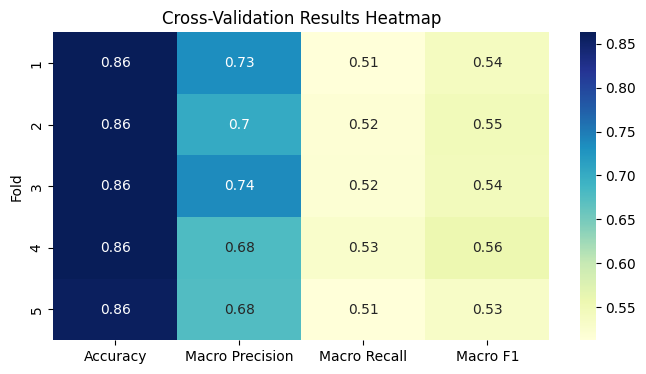

In [76]:
plt.figure(figsize=(8,4))

sns.heatmap(
    cv_results.set_index("Fold"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Cross-Validation Results Heatmap")

plt.show()

Ablation Study

In [ ]:
class SequenceDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

class BiLSTM_IDS(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_classes):

        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        return self.fc(out)

class FocalLoss(nn.Module):

    def __init__(self, gamma=2):

        super().__init__()

        self.gamma = gamma

        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):

        ce_loss = self.ce(inputs, targets)

        pt = torch.exp(-ce_loss)

        loss = ((1-pt)**self.gamma) * ce_loss

        return loss


def run_experiment(
    name,
    X_train,
    y_train,
    X_test,
    y_test,
    use_focal=False,
    use_sampler=False
):

    print("\nRunning:", name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    input_dim = X_train.shape[2]
    num_classes = len(np.unique(y_train))

    model = BiLSTM_IDS(input_dim, 128, num_classes).to(device)

    train_dataset = SequenceDataset(X_train, y_train)
    test_dataset = SequenceDataset(X_test, y_test)

    if use_sampler:

        class_counts = np.bincount(y_train)

        weights = 1.0 / class_counts

        sample_weights = weights[y_train]

        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

        train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)

    else:

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    test_loader = DataLoader(test_dataset, batch_size=128)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    if use_focal:

        criterion = FocalLoss()

    else:

        criterion = nn.CrossEntropyLoss()

    epochs = 10

    model.train()

    for epoch in range(epochs):

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y_batch.numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, average="macro")

    recall = recall_score(y_true, y_pred, average="macro")

    f1 = f1_score(y_true, y_pred, average="macro")

    return {
        "Variant": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [82]:
results = []

results.append(run_experiment(
    "Baseline",
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq
))

results.append(run_experiment(
    "Focal Loss",
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    use_focal=True
))

results.append(run_experiment(
    "Weighted Sampling",
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    use_sampler=True
))

results.append(run_experiment(
    "Focal + Weighted Sampling",
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    use_focal=True,
    use_sampler=True
))

results.append(run_experiment(
    "Seq-CGAN + Focal + Weighted",
    X_train_aug_seq,
    y_train_aug_seq,
    X_test_seq,
    y_test_seq,
    use_focal=True,
    use_sampler=True
))


Running: Baseline

Running: Focal Loss

Running: Weighted Sampling

Running: Focal + Weighted Sampling

Running: Seq-CGAN + Focal + Weighted


In [92]:
report_baseline = classification_report(
    y_true_baseline,
    y_pred_baseline,
    output_dict=True
)

report_seqcgan = classification_report(
    y_true_seqcgan,
    y_pred_seqcgan,
    output_dict=True
)

In [ ]:
report_baseline = classification_report(
    y_test_seq,
    y_pred_baseline,
    target_names=label_encoder.classes_,
    output_dict=True
)

In [ ]:
for r in results:

    micro_f1 = f1_score(
        r["y_true"],
        r["y_pred"],
        average="micro"
    )

    print(f"{r['Variant']} → Micro F1: {micro_f1:.4f}")

Baseline → Micro F1: 0.8632
Focal Loss → Micro F1: 0.8633
Weighted Sampling → Micro F1: 0.8369
Focal + Weighted Sampling → Micro F1: 0.8219
Seq-CGAN + Focal + Weighted → Micro F1: 0.8356


In [ ]:
micro_scores = []

for r in results:

    micro = f1_score(r["y_true"], r["y_pred"], average="micro")

    micro_scores.append(micro)

results_df["Micro F1"] = micro_scores

print(results_df)

                       Variant  Accuracy  Macro Precision  Macro Recall  \
0                     Baseline  0.863194         0.740872      0.540192   
1                   Focal Loss  0.863330         0.687160      0.517722   
2            Weighted Sampling  0.836901         0.528469      0.547969   
3    Focal + Weighted Sampling  0.821881         0.516218      0.549276   
4  Seq-CGAN + Focal + Weighted  0.835620         0.536008      0.552039   

   Macro F1                                             y_true  \
0  0.567599  [4, 5, 5, 3, 5, 7, 6, 4, 6, 2, 6, 6, 5, 3, 2, ...   
1  0.550907  [4, 5, 5, 3, 5, 7, 6, 4, 6, 2, 6, 6, 5, 3, 2, ...   
2  0.530405  [4, 5, 5, 3, 5, 7, 6, 4, 6, 2, 6, 6, 5, 3, 2, ...   
3  0.514874  [4, 5, 5, 3, 5, 7, 6, 4, 6, 2, 6, 6, 5, 3, 2, ...   
4  0.535887  [4, 5, 5, 3, 5, 7, 6, 4, 6, 2, 6, 6, 5, 3, 2, ...   

                                              y_pred  Micro F1  
0  [2, 5, 5, 3, 5, 7, 6, 4, 6, 3, 6, 6, 5, 3, 2, ...  0.863194  
1  [2, 5, 5, 3, 5, 7, 

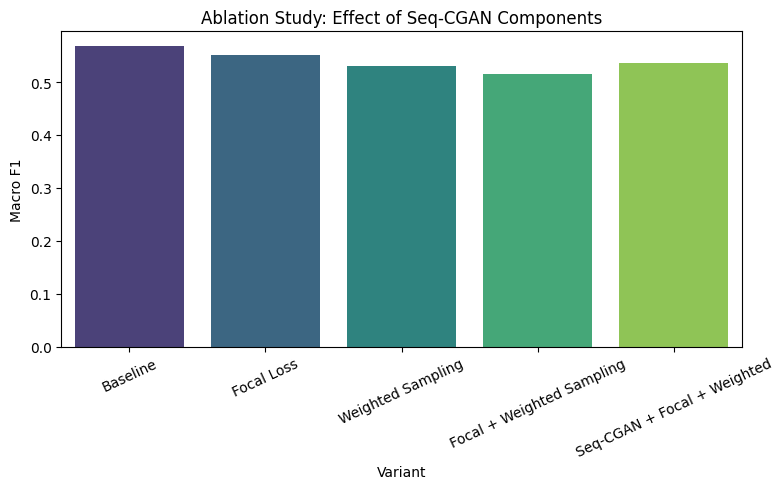

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Variant",
    y="Macro F1",
    palette="viridis"
)

plt.xticks(rotation=25)
plt.title("Ablation Study: Effect of Seq-CGAN Components")
plt.ylabel("Macro F1")

plt.tight_layout()
plt.show()

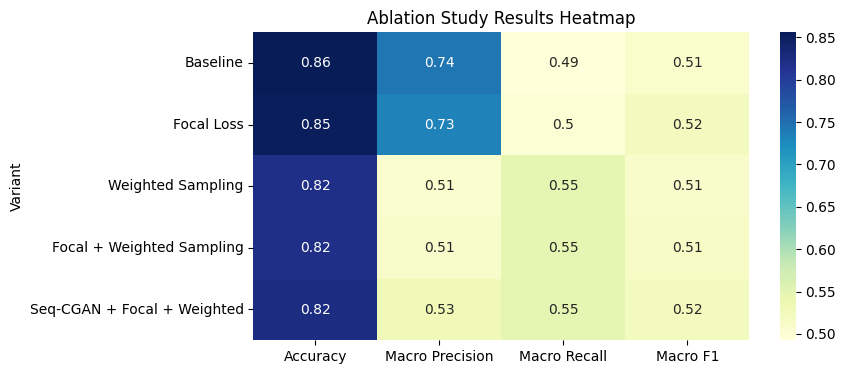

In [65]:
plt.figure(figsize=(8,4))

sns.heatmap(
    results_df.set_index("Variant"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Ablation Study Results Heatmap")

plt.show()